# LyricBERT
This notebook builds a recommendation system using **`brunokreiner/lyrics-bert`** — a BERT model fine-tuned on song lyrics — and compares it against all three previous models.

**What LyricBERT adds over TF-IDF and LSA:**  
TF-IDF and LSA operate on *surface vocabulary* — they measure what words appear, not what they mean. LyricBERT encodes each song into a dense semantic vector where words with similar meanings produce similar representations. "Heartbreak" and "falling apart" score near-zero similarity in TF-IDF but high similarity in LyricBERT because the model understands they carry the same meaning.

**Important note:**  
This notebook uses the Hugging Face `AutoTokenizer` and `AutoModel` workflow rather than the `SentenceTransformer(...)` wrapper because the wrapper caused version compatibility issues for this model.


## 1. Setup & Libraries

In [1]:
#!pip install transformers torch

In [2]:
import sys
sys.path.append('../src')

import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.decomposition import PCA

from lyricBERT_recommender import (
    build_lyricbert_recommender,
    recommend_songs
)
from tfidf_recommender  import build_tfidf_recommender,  recommend_songs as tfidf_recommend
from lsa_recommender    import build_lsa_recommender,    recommend_songs as lsa_recommend
from chorus_recommender import build_chorus_recommender, recommend_songs as chorus_recommend

pd.set_option('display.max_colwidth', 60)

## 2. Models 

In [3]:
LYRICS_PATH = '../data/processed/lyrics_clean.csv'
CHORUS_PATH = '../data/processed/chorus_clean.csv'
CACHE_DIR   = '../data/processed'

print('=== LyricBERT ===')
bert_df, embeddings, bert_sim = build_lyricbert_recommender(
    lyrics_path=LYRICS_PATH,
    cache_dir=CACHE_DIR
)

tfidf_df, tfidf_matrix, tfidf_sim = build_tfidf_recommender(LYRICS_PATH)
lsa_df, lsa_matrix, lsa_sim, svd, vec = build_lsa_recommender(LYRICS_PATH, n_components=100)
chorus_df, chorus_matrix, chorus_sim, chorus_vec = build_chorus_recommender(CHORUS_PATH)

print(f'\nAll models ready.')
print(f'LyricBERT embedding shape: {embeddings.shape}  (songs x embedding dimensions)')

=== LyricBERT ===
Loaded cached embeddings from ../data/processed/lyricbert_embeddings.npy | shape: (1502, 300)
Similarity matrix shape: (1502, 1502)

All models ready.
LyricBERT embedding shape: (1502, 300)  (songs x embedding dimensions)


## 3. Embedding Space - PCA Visualization

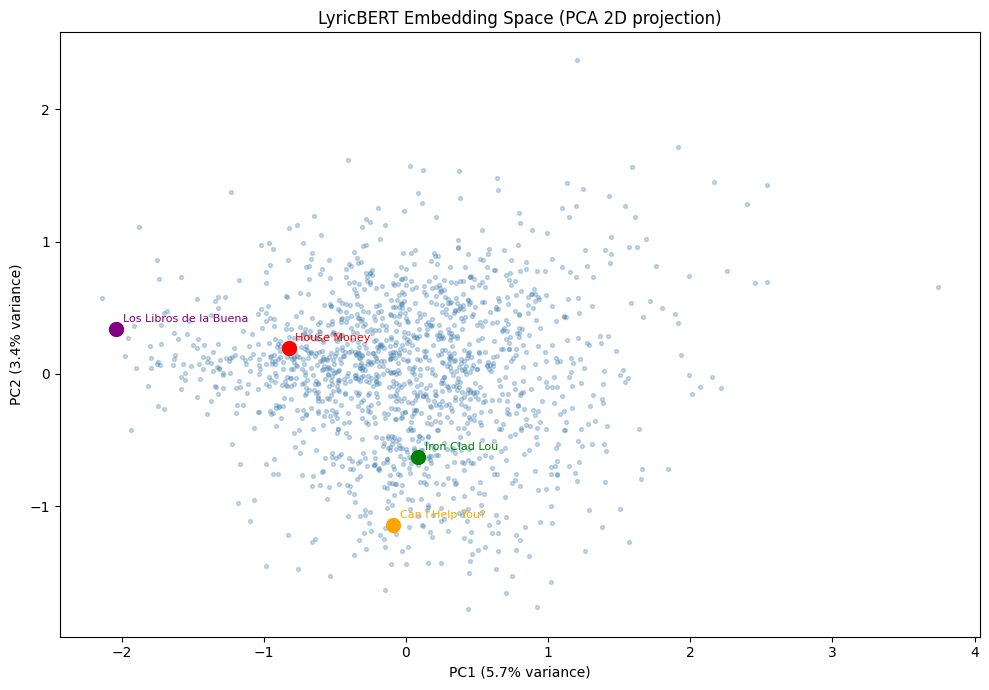

Total variance explained by 2 components: 9.0%
(Low % is expected — BERT embeddings are high-dimensional and resist 2D compression)


In [4]:
pca    = PCA(n_components=2, random_state=42)
coords = pca.fit_transform(embeddings)

fig, ax = plt.subplots(figsize=(10, 7))
ax.scatter(coords[:, 0], coords[:, 1], alpha=0.3, s=8, color='steelblue')

seeds = [
    ('House Money',                    'Baby Keem'),
    ('Iron Clad Lou',                  'Hum'),
    ("Can I Help You?",                'Amnesty'),
    ('Los Libros de la Buena Memoria', 'Invisible'),
]
colors = ['red', 'green', 'orange', 'purple']

for (title, artist), color in zip(seeds, colors):
    m = bert_df[
        (bert_df['track_name'].str.lower() == title.lower()) &
        (bert_df['artist'].str.lower()     == artist.lower())
    ]
    if not m.empty:
        idx = m.index[0]
        ax.scatter(coords[idx, 0], coords[idx, 1], color=color, s=100, zorder=5)
        ax.annotate(title[:22], (coords[idx, 0], coords[idx, 1]),
                    fontsize=8, xytext=(5, 5), textcoords='offset points', color=color)

ax.set_title('LyricBERT Embedding Space (PCA 2D projection)')
ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%} variance)')
ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%} variance)')
plt.tight_layout()
plt.show()

print(f'Total variance explained by 2 components: {pca.explained_variance_ratio_.sum():.1%}')
print('(Low % is expected — BERT embeddings are high-dimensional and resist 2D compression)')

The latin and hip-hop seeds are appear closer together, probably because the model is assoicating hip-hop adlibs with true latin vocabulary. The grunge and soul songs appear even closer together than latin and hip-hop. I hypothesize that this is because all of the models so far have struggled to capture soul or grung music well and the PCA plot is showing this struggle. 

## 4. Similarity Score Distribution: TF-IDF vs LyricBERT
LyricBERT scores behave very differently from TF-IDF, because all songs share a common semantic space. This allows even unrelated songs have moderate cosine similarit, meaning **raw scores are not comparable across models** — only rankings matter for comparison.

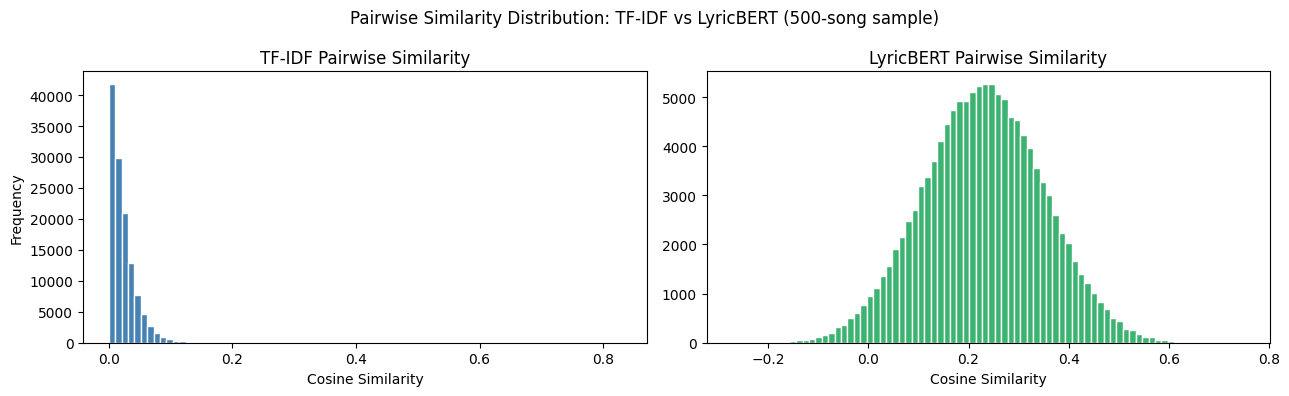

TF-IDF   :  mean=0.0233  median=0.0172  >0.3: 0.1%  >0.5: 0.0%  >0.9: 0.0%
LyricBERT:  mean=0.2295  median=0.2296  >0.3: 28.2%  >0.5: 1.1%  >0.9: 0.0%


In [5]:
sample_size = 500
rng = np.random.default_rng(42)
idx = rng.choice(len(bert_df), size=sample_size, replace=False)

bert_upper  = bert_sim[np.ix_(idx, idx)][np.triu_indices(sample_size, k=1)]
tfidf_upper = tfidf_sim[np.ix_(idx, idx)][np.triu_indices(sample_size, k=1)]

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].hist(tfidf_upper, bins=80, color='steelblue',      edgecolor='white')
axes[0].set_title('TF-IDF Pairwise Similarity')
axes[0].set_xlabel('Cosine Similarity')
axes[0].set_ylabel('Frequency')

axes[1].hist(bert_upper,  bins=80, color='mediumseagreen', edgecolor='white')
axes[1].set_title('LyricBERT Pairwise Similarity')
axes[1].set_xlabel('Cosine Similarity')

plt.suptitle('Pairwise Similarity Distribution: TF-IDF vs LyricBERT (500-song sample)')
plt.tight_layout()
plt.show()

for label, arr in [('TF-IDF   ', tfidf_upper), ('LyricBERT', bert_upper)]:
    print(f"{label}:  mean={arr.mean():.4f}  median={np.median(arr):.4f}  "
          f">0.3: {(arr>0.3).mean()*100:.1f}%  "
          f">0.5: {(arr>0.5).mean()*100:.1f}%  "
          f">0.9: {(arr>0.9).mean()*100:.1f}%")

The LyricBERT model has far higher mean and medial similarity across the coprus with a really nice normal distribution. This highlights the strength of using embeddings for a project like this one. 

## 5. LyricBERT Recommendations

In [6]:
def show_bert_recs(seed_title, seed_artist=None, k=10):
    recs = recommend_songs(
        bert_df, bert_sim,
        seed_title=seed_title, seed_artist=seed_artist, k=k
    )
    print(f"\nSeed: '{seed_title}'{' by ' + seed_artist if seed_artist else ''}")
    print('-' * 60)
    print(recs.to_string(index=True))
    return recs

bert_grunge = show_bert_recs('Iron Clad Lou',                  'Hum')
bert_soul   = show_bert_recs("Can I Help You?",                'Amnesty')
bert_latin  = show_bert_recs('Los Libros de la Buena Memoria', 'Invisible')
bert_hiphop = show_bert_recs('House Money',                    'Baby Keem')


Seed: 'Iron Clad Lou' by Hum
------------------------------------------------------------
                        track_name                                 artist  similarity
0  You Don't Know The Shape I'm In                           MJ Lenderman    0.525735
1                      Peach Trees                  Ax and the Hatchetmen    0.510355
2                     Never Lonely                         Space Mountain    0.508147
3                          Cadence                         The Long Faces    0.506061
4                  Need You Around                          Smoking Popes    0.504594
5               Just Another Honky                                  Faces    0.484613
6                         Doghouse                  Trudy and the Romance    0.479031
7                       House Fire  Someone Still Loves You Boris Yeltsin    0.467930
8          Ease Yourself and Glide                          Parsley Sound    0.467269
9               I Know How You Get               

**Grunge**: Even with powerful LyricBert embeddings, the grunge genre is not captured in the similarity rankings, although the scores are quite high. However, using my knowledge of the songs listed, I can see an "emo" theme appearing. It should also be highlighted that, while grunge itself isn't captured, all models did well identifying rock songs. This isn't a strong case, however, because the corpus of my liked songs is dominated by rock music already. 

**Soul**: Not a single soul song made the top-10 similarity list, although the similarity scores are high. This further supports the claim I made when looking at the PCA plot that both grunge and soul are harder to capture because their representation in music is heavily realted to their musical compostion. 

**Latin**: Very high similarity scores across the board, but there are fewer latin songs on the list compared to previous models. I think the embeddings are so strong that they can't decipher between adlibs and latin vocabulary; a problem seen across the board for all my models. 

**Hip-hop**: Something new we haven't seen in any other model: the similarities scores for hip-hop are lower than latin music. It's posssible the embeddings are down playing the weight of adlibs, contradicting my previous hypothesis about adlibs being confused for latin vocabulary. Another reason for these lower scores coud be down weighting of explicatives. My point being, the embeddings for adlibs and explicatives may not be as dense compared to other words, but they are repeating constantly in hip-hop. 

## 6. Four Model Comparison

In [8]:
def four_model_compare(seed_title, seed_artist=None, k=10):
    def safe_rec(fn, df, sim):
        try:
            return fn(df, sim, seed_title=seed_title, seed_artist=seed_artist, k=k)
        except ValueError:
            return None

    results = {
        'TF-IDF':    safe_rec(tfidf_recommend,  tfidf_df,  tfidf_sim),
        'LSA':       safe_rec(lsa_recommend,     lsa_df,    lsa_sim),
        'Chorus':    safe_rec(chorus_recommend,  chorus_df, chorus_sim),
        'LyricBERT': safe_rec(recommend_songs,   bert_df,   bert_sim),
    }

    print(f"\nSeed: '{seed_title}'{' by ' + seed_artist if seed_artist else ''}")
    header = f"{'#':<4}" + "".join(f" {('── ' + n + ' ──'):<36}" for n in results)
    print(header)
    print('-' * (4 + 36 * len(results)))

    for i in range(k):
        row = f"{i+1:<4}"
        for recs in results.values():
            if recs is None or i >= len(recs):
                row += f" {'[not found]':<36}"
            else:
                r     = recs.iloc[i]
                entry = f"{r['track_name'][:20]} / {r['artist'][:12]}"
                row  += f" {entry:<36}"
        print(row)

    return results

res_grunge = four_model_compare('Iron Clad Lou',                  'Hum')
res_soul   = four_model_compare('Everybody Loves The Sunshine',   'Roy Ayers Ubiquity')
res_latin  = four_model_compare('Heaven Knows',                   '54 Ultra')
res_hiphop = four_model_compare('House Money',                    'Baby Keem')


Seed: 'Iron Clad Lou' by Hum
#    ── TF-IDF ──                         ── LSA ──                            ── Chorus ──                         ── LyricBERT ──                     
----------------------------------------------------------------------------------------------------------------------------------------------------
1    Stand up and Win / Spymob            muscles / not dvr                    Faxing It In / Smushie               You Don't Know The S / MJ Lenderman 
2    Never Lonely / Space Mounta          Never Lonely / Space Mounta          The Great Salt Lake / Band of Hors   Peach Trees / Ax and the H          
3    Downtown / Varsity                   Wake up Jacob / Sitcom               Belief / John Mayer                  Never Lonely / Space Mounta         
4    Rain / World's Expe                  Lonely Mess / Laundry                Weird Fishes / Arpeg / Radiohead     Cadence / The Long Fac              
5    Faxing It In / Smushie               Hell N Back / 

**Grunge**: Out of all four models, only one grunge song was found. As I've said during all tests, the grunge genre is better defined by its hardcore rock sound than its lyrical. When initally setting up the seeds, I thought grunge would be decently covered across testing given the usual "emo" lyrics that the genre is associated with, but that wasn't the case here. Obviously it should be mentioned that these test are biased to specific song I picked, but the consistent results across models still shows a clear discrepancy. 

**Soul**: Out of all four models, only three soul songs were found; four if you count funkadelic, but that is debatable. My argument for the poor results in identifying grunge are seen in soul as well. However, this is surprising to me becasue I associate soul music with lyrical themes around love, spirituality, black pride, and the fight for equality during the civil rights movmenet. None of the models picked up these themes, even the LSA, which I hoped would pick up on these themes. 

**Latin**: Here the results need to be put in context. The seed song is by a latin artist with a few parts sung in Spanish, but is otherwise in english. So, I'm not surpsied not a single latin song made any of the lists. Further analysis would need to be done with preprocessing that translates the latin songs into english, but given the low amount of latin songs in the corpus I thought it would do well enough capturing that distinction. 

**Hip-hop**: All the recommmenders except the chorus only model did well with hip-hop. Every single song across the baseline TF-IDF, LSA, and LyricBERT models correctly identified hip-hop songs 10 out of 10 times. As I've stated in every indivudal test, I believe these models are good at picking up on the hip-hop due to the consistent use of adlibs and explicatives across the genre. The chorus models worse performance further proves this point because the chorus usually contains the main message of a song as opposed to the repeated adlibs and explicatives used throughout hip-hop songs. 

## 7. Jaccard Similarity Heatmaps

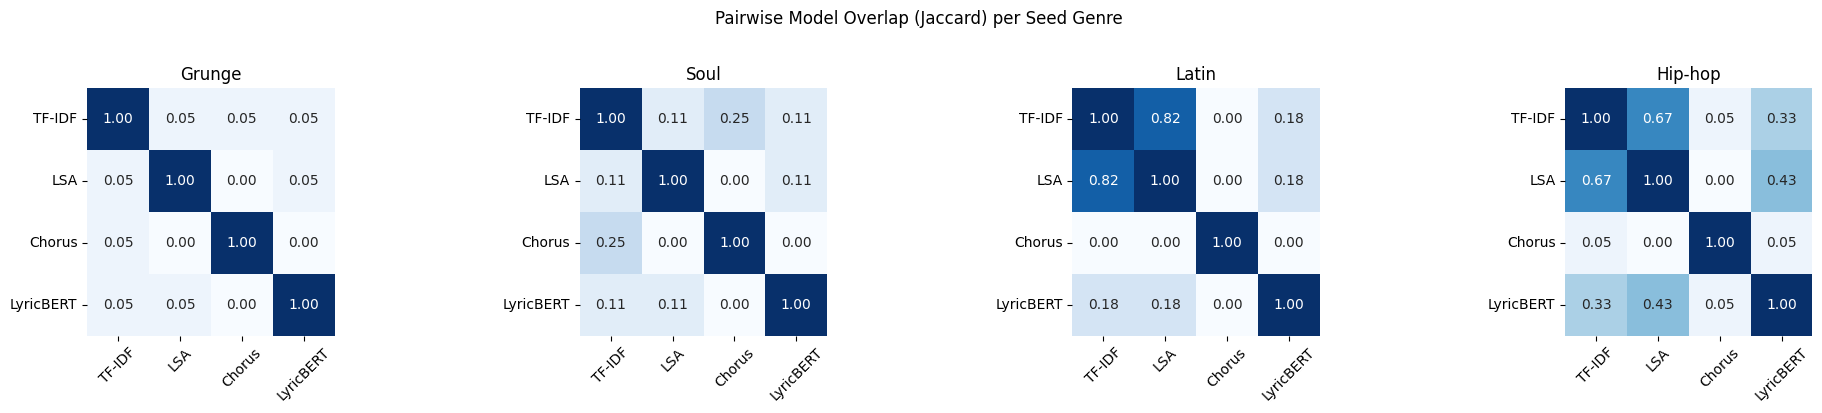

In [9]:
def jaccard(a, b):
    if a is None or b is None:
        return np.nan
    sa = set(zip(a['track_name'], a['artist']))
    sb = set(zip(b['track_name'], b['artist']))
    return len(sa & sb) / len(sa | sb)

def overlap_matrix(results):
    models = list(results.keys())
    mat = pd.DataFrame(index=models, columns=models, dtype=float)
    for a in models:
        for b in models:
            mat.loc[a, b] = 1.0 if a == b else jaccard(results[a], results[b])
    return mat

genre_results = [
    (res_grunge, 'Grunge'),
    (res_soul,   'Soul'),
    (res_latin,  'Latin'),
    (res_hiphop, 'Hip-hop'),
]

fig, axes = plt.subplots(1, 4, figsize=(20, 4))
for ax, (results, title) in zip(axes, genre_results):
    mat = overlap_matrix(results)
    sns.heatmap(
        mat.astype(float), annot=True, fmt='.2f',
        vmin=0, vmax=1, cmap='Blues',
        ax=ax, cbar=False, square=True
    )
    ax.set_title(title)
    ax.tick_params(axis='x', rotation=45)
    ax.tick_params(axis='y', rotation=0)

plt.suptitle('Pairwise Model Overlap (Jaccard) per Seed Genre', y=1.02)
plt.tight_layout()
plt.show()

Almost no similarities were found between models for the grunge and soul genres, which is consistent with my findings throughout this project. However, the TF-IDF, LSA, and LyricBert were seeing strong overlap for Latin and Hip-hop. This surprises me because they use very different approaches to create their recommendations. One possible explanation for this could be that the signals for latin music and hip-hop in the corpus were much easier to identify than grunge and soul regardless of modeling approach. Furthermore, I think these resutls show that, based on my corpus of songs, the LyricBERT model's full potential isn't being realized, and a similar arugment could be made for LSA. If I had more time on this project I would defintely increase the size of the corpus and expand the diversity of songs. Although it should be noted that the corpus already has far more grunge and soul music included than it does latin or hip-hop, so my point about grunge and soul being better represented by musical compostion is further proven.

## 8. LyricBERT Unqiue Recommendations

In [11]:
def bert_unique(results, label):
    if results['LyricBERT'] is None:
        print(f"{label}: LyricBERT result not found\n")
        return

    bert_set  = set(zip(results['LyricBERT']['track_name'],
                        results['LyricBERT']['artist']))
    other_set = set()
    for name, recs in results.items():
        if name != 'LyricBERT' and recs is not None:
            other_set |= set(zip(recs['track_name'], recs['artist']))

    unique = bert_set - other_set
    shared = bert_set & other_set

    print(f"{label}")
    print(f"  Unique to LyricBERT:         {len(unique)}")
    for t, a in unique:
        print(f"    → {t} — {a}")
    print(f"  Shared with ≥1 other model:  {len(shared)}")
    print()

bert_unique(res_grunge, 'Grunge (Iron Clad Lou)')
bert_unique(res_soul,   'Soul (Everybody Loves the Sunshine)')
bert_unique(res_latin,  'Latin (Heaven Knows)')
bert_unique(res_hiphop, 'Hip-hop (House Money)')

Grunge (Iron Clad Lou)
  Unique to LyricBERT:         9
    → Doghouse — Trudy and the Romance
    → Peach Trees — Ax and the Hatchetmen
    → Need You Around — Smoking Popes
    → I Know How You Get — Mk.gee
    → Ease Yourself and Glide — Parsley Sound
    → Cadence — The Long Faces
    → Just Another Honky — Faces
    → House Fire — Someone Still Loves You Boris Yeltsin
    → You Don't Know The Shape I'm In — MJ Lenderman
  Shared with ≥1 other model:  1

Soul (Everybody Loves the Sunshine)
  Unique to LyricBERT:         7
    → I Thought You Had The Lighter? — Mexican Slum Rats
    → Sweetest Thing on This Side of Heaven — Papa Bear & His Cubs
    → Time Being — Surface To Air Missive
    → Changes — Charles Bradley
    → Rom-Com Gone Wrong — Matt Maltese
    → Between Days — Red House Painters
    → Spit on a Stranger — Pavement
  Shared with ≥1 other model:  3

Latin (Heaven Knows)
  Unique to LyricBERT:         7
    → You And Me — Penny & The Quarters
    → ･－･･ ･ － ･･ － －－･ －－

**Grunge**: The only observation I feel I can make is that most of the unqiue songs have a "emo" feeling, although that isn't strong evidence. 

**Soul**: Not much to say here, this is a collection of completely random songs aside from "Sweetest Thing on This Side of Heaven" which is a great soul song. 

**Latin**: Interestingly, there are more soul songs on this list than for the soul test. I think this has to do with the discrepancies between seeds I picked, because "Heaven Knows" hits on the spirituality and love themes I would recognize in soul music. 

**Hip-hop**: To no surprise this genre has the lowest amount of unqiue songs, and the three unqiue ones are all in the hip-hop genre as well. 

## 9. Obserations